# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

Answer to Q1: A model is linear when it is linear in its coefficients. This means that the prediction is created by adding terms up where each coefficient is simply multiplied by a variable and then combined. The input variables themselves can be transformed for example, squared or log-transformed. However, as long as the coefficients still enter the equation in both an additive and multiplicative way, the model is linear.

Answer to Q2: The coefficient on a dummy variable represents the difference in the expected value of y between that category and the baseline category, holding everything else constant. The intercept then represents the expected y for the baseline group and you also need to drop one category because if you don't it can cause multicollinearlity which means that the dummy variables will always sum to 1 and perfectly predict the intercept, making it impossible for the model to uniquely estimate the coefficients.

Answer to Q3: Linear regression can be used for classification, however, it is not recommended. This is because continuous values can fall outside [0, 1], making them hard to interpret as probabilities.

Answer to Q4: Some of the signs that my linear model is over-fitting is if the training R^2 is higher than the test R^2, there is a large gap between the training and the test error, the model has too many features that are relative to the number of observations, the coefficients are too large in magnitude, and finally performance decreases significantly on the new data. 

Answer to Q5: Multicollinearity occurs when two or more independent variables are highly correlated, making it difficult to isolate each variable's individual effect and causing coefficient estimates to become unstable. Two-Stage Least Squares (2SLS) helps illustrate how to deal with this kind of problem. In the first stage, you regress the problematic variable on an instrument, which is a variable that is correlated with x but has nothing to do with the error in your model. The fitted values from that first regression are then plugged into the second stage in place of the original variable. Basically, you are swapping out the messy, correlated version of the variable for a cleaner version of it, so your coefficient estimates are more reliable.

Answer to Q6: You can add transformed features to a linear model such as polynomials, logarithms, and interaction terms. The model remains linear in parameters even though the relationship between y and the original x is nonlinear.

Answer to Q7: The slope coefficient represents the expected change in y for a one-unit increase in x, holding all other variables constant. 

Answer to Q8: In a train/test split, the data is divided once into two sets, one for training and one for evaluating the model. This is simple and cheap to run, but the performance estimate can be unreliable since it depends heavily on which observations happened to end up in each set. K-fold cross validation improves on this by splitting the data into k equal groups. The model is trained k times, and each time a different group is used as the test set while the rest are used for training. The final performance score is just the average across all k runs, which gives a more stable and reliable estimate. The downside is that you have to fit the model k times, which takes more computing power, but for smaller datasets it is usually worth it for the more trustworthy estimate.

Answer to Q9: Common choices are k = 5 or k = 10, as these provide a good bias-variance tradeoff in the error estimate. A larger k gives a less biased estimate but is computationally expensive and has high variance. The choice often depends on dataset size. For example, smaller datasets benefit from larger k to maximize training data.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import warnings

df = pd.read_csv('./Q1_clean.csv')
df = df.rename(columns={'Review Scores Rating': 'Review_Scores_Rating'})
df.columns = df.columns.str.strip()  

print(df.head())
print(df.shape)

   Price  Review_Scores_Rating Neighbourhood Property Type        Room Type
0    549                  96.0     Manhattan     Apartment     Private room
1    149                 100.0      Brooklyn     Apartment  Entire home/apt
2    250                 100.0     Manhattan     Apartment  Entire home/apt
3     90                  94.0      Brooklyn     Apartment     Private room
4    270                  90.0     Manhattan     Apartment  Entire home/apt
(22153, 5)


                    Price  Review_Scores_Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378

Most expensive neighborhood on average: Manhattan


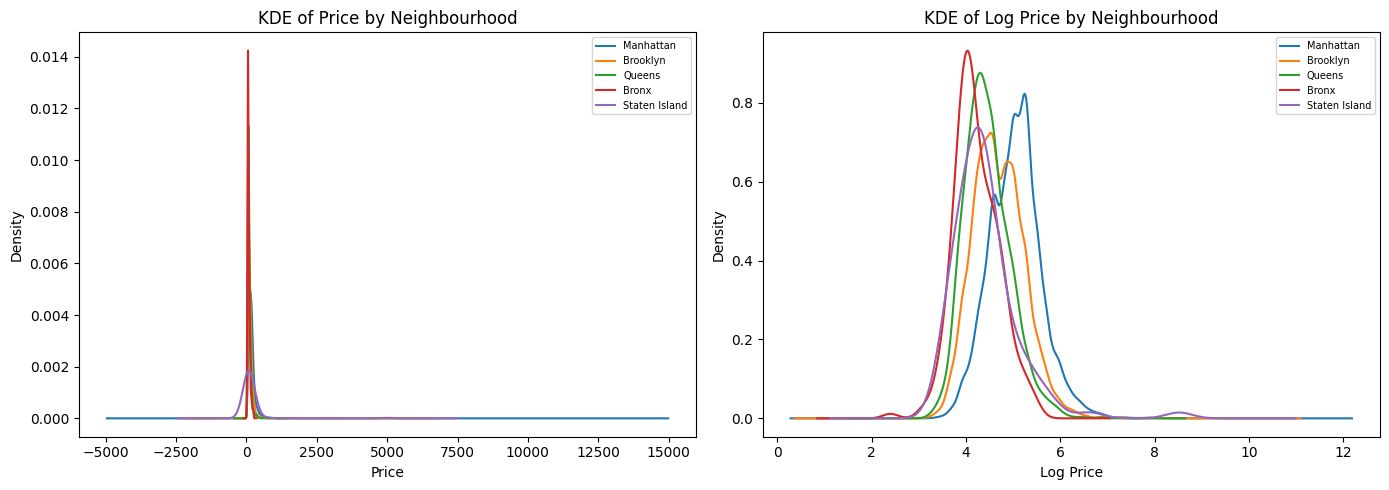

In [35]:
# Q2.1 
avg_by_neighborhood = df.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']].mean().sort_values('Price', ascending=False)
print(avg_by_neighborhood)
print("\nMost expensive neighborhood on average:", avg_by_neighborhood['Price'].idxmax())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == hood]['Price']
    subset.plot.kde(ax=axes[0], label=hood)

axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].legend(fontsize=7)

df['Log_Price'] = np.log1p(df['Price'])
for hood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == hood]['Log_Price']
    subset.plot.kde(ax=axes[1], label=hood)

axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

#Overall, the dataset shows that the most expensive neighborhood is Manhattan on average. 

In [36]:
# Q2.2 
neigh_dum = pd.get_dummies(df['Neighbourhood'], drop_first=True)
X_q2 = neigh_dum.astype(int)
y = df['Price']

model_q2 = LinearRegression()
model_q2.fit(X_q2, y)

coef_df = pd.DataFrame({
    'Neighbourhood': neigh_dum.columns,
    'Coefficient': model_q2.coef_
})
print("Intercept (dropped category mean):", model_q2.intercept_)
print(coef_df)
print("\nGroup means:")
print(df.groupby('Neighbourhood')['Price'].mean())


#For Q2.2, we dropped the first category (Bronx) and kept the intercept to avoid the dummy variable trap. The intercept comes out to 75.28, 
# which is exactly the Bronx group mean, and each coefficient represents how much more or less expensive that neighborhood is relative to 
# the Bronx. You can add add the intercept to any coefficient to get the neighborhood's group mean for example, 75.28 + 108.39 = 183.67, 
# which closely matches Manhattan's group mean of 183.66. So the conditional group means and the regression coefficients are really just 
# two ways of saying the same thing, with the regression expressing group means as differences from the Bronx rather than raw averages.

Intercept (dropped category mean): 75.27649769584711
   Neighbourhood  Coefficient
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169

Group means:
Neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64


In [37]:
# Q2.3 - Regress price on Review_Scores_Rating
X_q3 = df[['Review_Scores_Rating']]
model_q3 = LinearRegression()
model_q3.fit(X_q3, y)

print("Intercept:", model_q3.intercept_)
print("Slope on Review_Scores_Rating:", model_q3.coef_[0])
print("\nInterpretation: A one-unit increase in Review_Scores_Rating is associated with a",
      round(model_q3.coef_[0], 4), "change in Price.")

Intercept: 60.87839065711856
Slope on Review_Scores_Rating: 1.0208266022675305

Interpretation: A one-unit increase in Review_Scores_Rating is associated with a 1.0208 change in Price.


In [38]:
# Q2.4
X_q4 = pd.concat([neighbourhood_dummies.astype(int), df[['Review_Scores_Rating']]], axis=1)
model_q4 = LinearRegression()
model_q4.fit(X_q4, y)

coef_q4 = pd.DataFrame({
    'Feature': list(neighbourhood_dummies.columns) + ['Review_Scores_Rating'],
    'Coefficient': model_q4.coef_
})
print("Intercept:", model_q4.intercept_)
print(coef_q4)
print("\nCompare Review_Scores_Rating slope:")
print("  Q2.3 (without neighbourhood):", round(model_q3.coef_[0], 4))
print("  Q2.4 (with neighbourhood):", round(model_q4.coef_[-1], 4))


#When we add Neighbourhood to the regression alongside Review_Scores_Rating, the slope on Review_Scores_Rating barely changes as it
# goes from 1.0208 to 1.0811 in this question, so controlling for neighbourhood doesn't really shift it much. This suggests that
#Review_Scores_Rating and Neighbourhood aren't strongly correlated with each other. However, the neighbourhood averages do shift 
# slightly because we can see that Brooklyn drops from 52.47 to 51.70 and Manhattan from 108.39 to 108.23, etc. 

Intercept: -23.8125610116752
                Feature  Coefficient
0              Brooklyn    51.704240
1             Manhattan   108.228737
2                Queens    21.694600
3         Staten Island    71.766552
4  Review_Scores_Rating     1.081116

Compare Review_Scores_Rating slope:
  Q2.3 (without neighbourhood): 1.0208
  Q2.4 (with neighbourhood): 1.0811


In [39]:
# Q2.5 
X_q5 = pd.DataFrame()

for hood in df['Neighbourhood'].unique():
    X_q5[f'Review_Scores_Rating_{hood}'] = (
        df['Review_Scores_Rating'] * (df['Neighbourhood'] == hood)
    )

X_q5 = pd.concat([neighbourhood_dummies.astype(int), X_q5], axis=1)

model_q5 = LinearRegression()
model_q5.fit(X_q5, y)

rating_cols = [c for c in X_q5.columns if c.startswith('Review_Scores_Rating_')]
slopes = {col.replace('Review_Scores_Rating_', ''): coef 
          for col, coef in zip(X_q5.columns, model_q5.coef_) 
          if col in rating_cols}

print("Slope on Review_Scores_Rating per Neighbourhood:")
for hood, slope in slopes.items():
    print(f"  {hood}: {round(slope, 4)}")

#The slopes are not similar across neighbourhoods. Manhattan and Brooklyn has a Review_Scores_Rating of 1.30, while Queens and Bronx are around 
# 0.50 and 0.57 respectively, and Staten Island is at -31.26. 

Slope on Review_Scores_Rating per Neighbourhood:
  Manhattan: 1.304
  Brooklyn: 1.3155
  Queens: 0.502
  Bronx: 0.5743
  Staten Island: -31.2574


In [40]:
# Q2.6
warnings.filterwarnings('ignore')

X_q4_clean = X_q4.dropna()
y_q4_clean = y[X_q4_clean.index]

X_q5_clean = X_q5.dropna()
y_q5_clean = y[X_q5_clean.index]

models = {
    'Q2.4 (Neighbourhood + Rating)': (X_q4_clean, y_q4_clean),
    'Q2.5 (Interaction model)':       (X_q5_clean, y_q5_clean),
}

for name, (X, y_clean) in models.items():
    scores = cross_val_score(LinearRegression(), X, y_clean, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    print(f"{name}")
    print(f"  Mean RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}\n")

Q2.4 (Neighbourhood + Rating)
  Mean RMSE: 142.8265 ± 26.7153

Q2.5 (Interaction model)
  Mean RMSE: 143.8609 ± 26.8756



**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


       Unnamed: 0    Make_Year   Mileage_Run  Seating_Capacity         Price
count  976.000000   976.000000    976.000000        976.000000  9.760000e+02
mean   488.500000  2016.963115  41571.195697          5.095287  7.410195e+05
std    281.891232     2.818742  24390.995134          0.446224  3.673234e+05
min      1.000000  2011.000000   1117.000000          4.000000  1.880000e+05
25%    244.750000  2015.000000  22676.750000          5.000000  4.757500e+05
50%    488.500000  2017.000000  37570.500000          5.000000  6.665000e+05
75%    732.250000  2019.000000  57421.250000          5.000000  8.830000e+05
max    976.000000  2022.000000  99495.000000          8.000000  2.941000e+06

Price by Body_Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837 

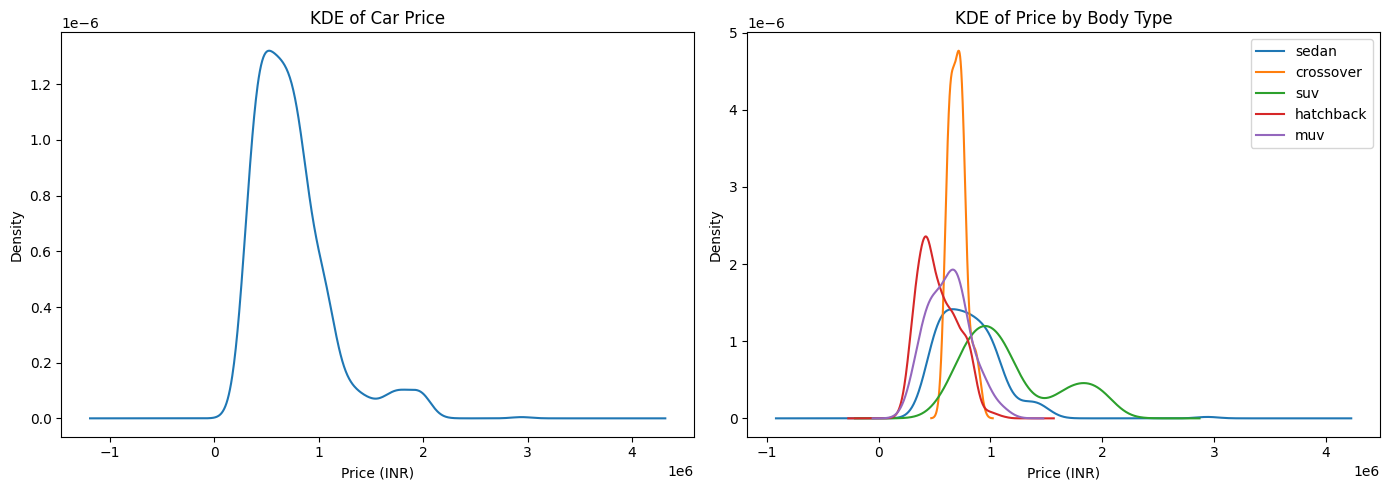


Most expensive by mean: suv
Most variance by std: suv


In [41]:
# Q3.1
cars = pd.read_csv('./data/cars_hw.csv')
print(cars.describe())
print("\nPrice by Body_Type:")
print(cars.groupby('Body_Type')['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cars['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Car Price')
axes[0].set_xlabel('Price (INR)')

for body in cars['Body_Type'].unique():
    subset = cars[cars['Body_Type'] == body]['Price']
    subset.plot.kde(ax=axes[1], label=body)
axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlabel('Price (INR)')
axes[1].legend()
plt.tight_layout()
plt.show()

print("\nMost expensive by mean:", cars.groupby('Body_Type')['Price'].mean().idxmax())
print("Most variance by std:", cars.groupby('Body_Type')['Price'].std().idxmax())

In [44]:
# Q3.2 
y_cars = cars['Price']
X_seats_cont = cars[['Seating_Capacity']]
model_seats_cont = LinearRegression().fit(X_seats_cont, y_cars)
print("Seating_Capacity as continuous")
print("Intercept:", model_seats_cont.intercept_)
print("Slope:", model_seats_cont.coef_[0])
print("Interpretation: Each additional seat is associated with a price change of",
      round(model_seats_cont.coef_[0], 2), "INR")

seats_dummies = pd.get_dummies(cars['Seating_Capacity'].astype(str), drop_first=True).astype(int)
model_seats_cat = LinearRegression().fit(seats_dummies, y_cars)
print("\nSeating_Capacity as categorical (one-hot)")
coef_seats = pd.DataFrame({'Seats': seats_dummies.columns, 'Coefficient': model_seats_cat.coef_})
print("Intercept:", model_seats_cat.intercept_)
print(coef_seats)

#The differences are not perfectly linear because the gaps between coefficients are pretty uneven, 
# so treating Seating_Capacity as continuous oversimplifies the relationship.

Seating_Capacity as continuous
Intercept: 439032.0141018258
Slope: 59267.99803672191
Interpretation: Each additional seat is associated with a price change of 59268.0 INR

Seating_Capacity as categorical (one-hot)
Intercept: 188000.00000001153
  Seats   Coefficient
0     5  5.464839e+05
1     6  1.456000e+06
2     7  7.359487e+05
3     8  2.718000e+05


In [ ]:
# Q3.3 
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

current_year = 2024
cars['Age'] = current_year - cars['Make_Year']

degrees = range(1, 11)
cv_rmse = []

for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    scores = cross_val_score(pipe, cars[['Age']], y_cars, cv=10,
                             scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores).mean()
    cv_rmse.append(rmse)
    print(f"Degree {d}: Mean CV RMSE = {rmse:.2f}")

best_degree = degrees[np.argmin(cv_rmse)]
print(f"\nOptimal degree: {best_degree}")

Degree 1: Mean CV RMSE = 307576.54
Degree 2: Mean CV RMSE = 308059.75
Degree 3: Mean CV RMSE = 307440.79
Degree 4: Mean CV RMSE = 307881.11
Degree 5: Mean CV RMSE = 307742.22
Degree 6: Mean CV RMSE = 308128.07
Degree 7: Mean CV RMSE = 307251.17
Degree 8: Mean CV RMSE = 306482.12
Degree 9: Mean CV RMSE = 307034.38
Degree 10: Mean CV RMSE = 307532.87

Optimal degree: 8


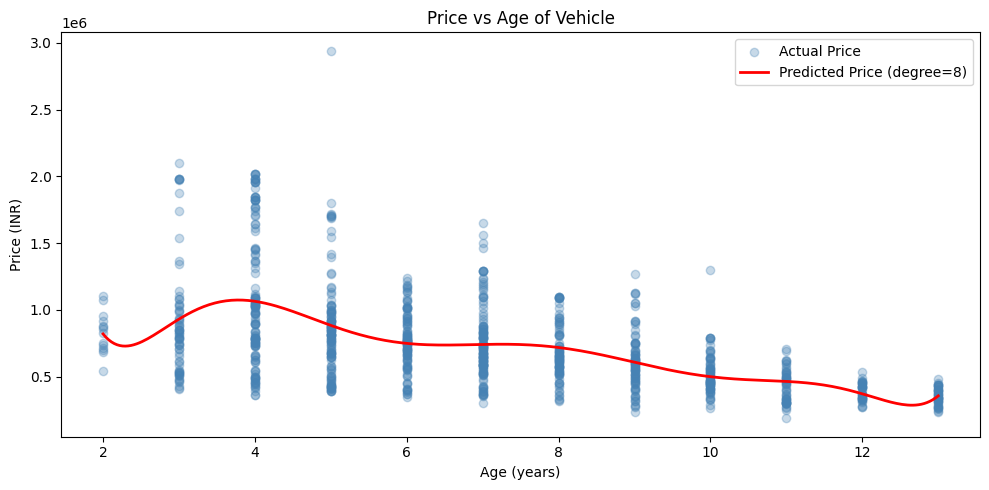

In [ ]:
# Q3.4 
best_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model', LinearRegression())
])
best_pipe.fit(cars[['Age']], y_cars)

age_range = np.linspace(cars['Age'].min(), cars['Age'].max(), 300).reshape(-1, 1)
predicted_prices = best_pipe.predict(age_range)

plt.figure(figsize=(10, 5))
plt.scatter(cars['Age'], y_cars, alpha=0.3, label='Actual Price', color='steelblue')
plt.plot(age_range, predicted_prices, color='red', linewidth=2,
         label=f'Predicted Price (degree={best_degree})')
plt.title('Price vs Age of Vehicle')
plt.xlabel('Age (years)')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

#The model captures the general downward trend: newer cars (age 2-4) tend to be priced higher, and prices decline as cars get older.
#  However, the degree-8 polynomial curve moves up and down quite a bit rather than following a smooth decline, which could mean that it is
#  overfitting to noise in the data rather than capturing the true underlying pattern. The actual prices also have a lot of variance 
# at every age, so the model explains the trend but misses a lot of the spread.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [45]:
# Q4
heart = pd.read_csv('./heart_hw.csv')
print(heart.head())
print(heart.shape)
print(heart['transplant'].value_counts())

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
(103, 4)
transplant
treatment    69
control      34
Name: count, dtype: int64


In [46]:
# Q4.1 
control = heart[heart['transplant'] == 'control']
treatment = heart[heart['transplant'] == 'treatment']

prop_control = control['y'].mean()
prop_treatment = treatment['y'].mean()
ATE = prop_treatment - prop_control

print(prop_control)
print(prop_treatment)
print(ATE)

#The ATE on a three-year survival for heart transplant interventions is 0.23.

0.11764705882352941
0.34782608695652173
0.23017902813299232


In [ ]:
# Q4.2 
heart['transplant_binary'] = (heart['transplant'] == 'treatment').astype(int)

X_q4_2 = heart[['transplant_binary']]
y_heart = heart['y']

model_q4_2 = LinearRegression().fit(X_q4_2, y_heart)

print("Regress y on transplant")
#intercept
print(prop_control)
#transplant coefficient
print(ATE)

#The intercept and the transplant coefficient matches the numbers I computed in part 1. 

Regress y on transplant
0.11764705882352941
0.23017902813299232


Regress y on transplant + age
Intercept:              0.7020
Transplant coefficient: 0.2647
Age coefficient:        -0.0136

Transplant coef changed from 0.2302 to 0.2647 after controlling for age


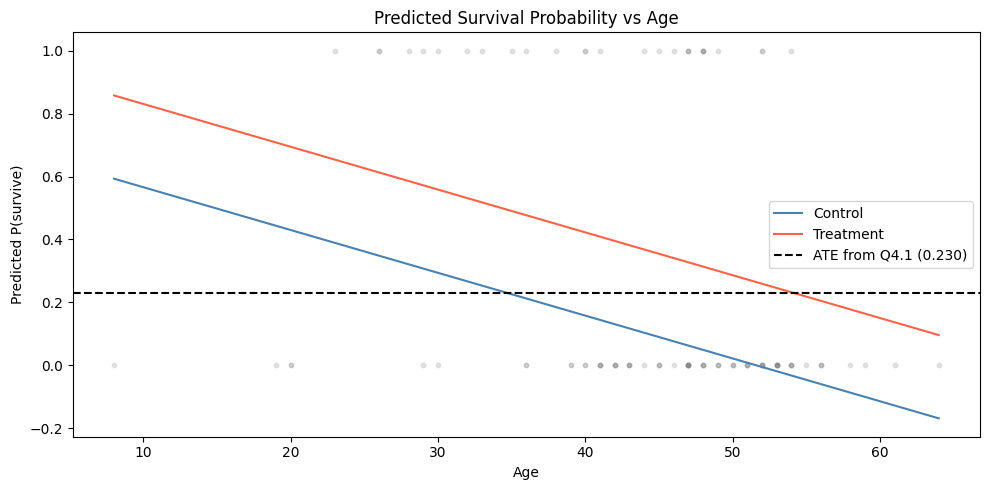

In [48]:
# Q4.3
X_q4_3 = heart[['transplant_binary', 'age']]
model_q4_3 = LinearRegression().fit(X_q4_3, y_heart)

print("Regress y on transplant + age")
print(f"Intercept:              {model_q4_3.intercept_:.4f}")
print(f"Transplant coefficient: {model_q4_3.coef_[0]:.4f}")
print(f"Age coefficient:        {model_q4_3.coef_[1]:.4f}")
print(f"\nTransplant coef changed from {model_q4_2.coef_[0]:.4f} to {model_q4_3.coef_[0]:.4f} after controlling for age")

#The intercept and the slope represents the predicted survival probability for a 0-year-old in the control group and the change in 
# predicted survival probability for each additional year of age, respectively.

age_range = np.linspace(heart['age'].min(), heart['age'].max(), 300)

pred_control = model_q4_3.intercept_ + model_q4_3.coef_[0]*0 + model_q4_3.coef_[1]*age_range
pred_treatment = model_q4_3.intercept_ + model_q4_3.coef_[0]*1 + model_q4_3.coef_[1]*age_range

plt.figure(figsize=(10, 5))
plt.plot(age_range, pred_control, label='Control', color='steelblue')
plt.plot(age_range, pred_treatment, label='Treatment', color='tomato')
plt.axhline(y=ATE, color='black', linestyle='--', label=f'ATE from Q4.1 ({ATE:.3f})')
plt.scatter(heart['age'], heart['y'], alpha=0.2, color='gray', s=10)
plt.title('Predicted Survival Probability vs Age')
plt.xlabel('Age')
plt.ylabel('Predicted P(survive)')
plt.legend()
plt.tight_layout()
plt.show()

#The ATE overestimates the transplant benefit for older patients (50+) where survival probabilities drop unrealistically low, and
#  underestimates it for younger patients where the flat 0.230 gap doesn't capture how much more impactful a transplant is at younger ages.

Regress y on transplant + age + transplant*age
Intercept:                0.3549
Transplant coefficient:   0.9078
Age coefficient:          -0.0055
Transplant*Age coef:      -0.0146


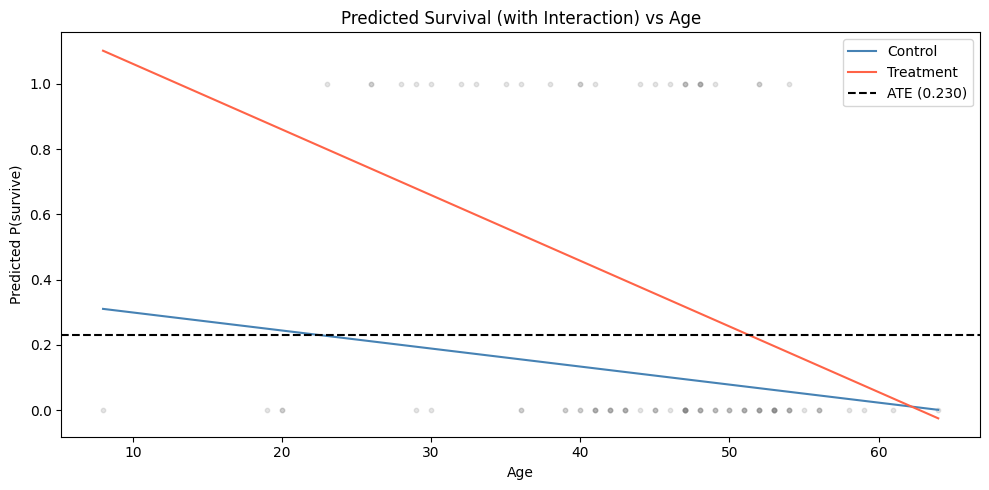

In [ ]:
# Q4.4 
heart['transplant_x_age'] = heart['transplant_binary'] * heart['age']

X_q4_4 = heart[['transplant_binary', 'age', 'transplant_x_age']]
model_q4_4 = LinearRegression().fit(X_q4_4, y_heart)

print("Regress y on transplant + age + transplant*age")
print(f"Intercept:                {model_q4_4.intercept_:.4f}")
print(f"Transplant coefficient:   {model_q4_4.coef_[0]:.4f}")
print(f"Age coefficient:          {model_q4_4.coef_[1]:.4f}")
print(f"Transplant*Age coef:      {model_q4_4.coef_[2]:.4f}")

pred_control_int = (model_q4_4.intercept_ + 
                    model_q4_4.coef_[0]*0 + 
                    model_q4_4.coef_[1]*age_range + 
                    model_q4_4.coef_[2]*0*age_range)

pred_treatment_int = (model_q4_4.intercept_ + 
                      model_q4_4.coef_[0]*1 + 
                      model_q4_4.coef_[1]*age_range + 
                      model_q4_4.coef_[2]*1*age_range)

plt.figure(figsize=(10, 5))
plt.plot(age_range, pred_control_int, label='Control', color='steelblue')
plt.plot(age_range, pred_treatment_int, label='Treatment', color='tomato')
plt.axhline(y=ATE, color='black', linestyle='--', label=f'ATE ({ATE:.3f})')
plt.scatter(heart['age'], heart['y'], alpha=0.2, color='gray', s=10)
plt.title('Predicted Survival (with Interaction) vs Age')
plt.xlabel('Age')
plt.ylabel('Predicted P(survive)')
plt.legend()
plt.tight_layout()
plt.show()

# Adding the interaction term allows the transplant benefit to vary with age rather than being fixed. 
# The transplant*age coefficient is -0.0146, meaning the benefit of a transplant decreases as patients get older. You can see this 
# in the plot where the gap between the treatment and control lines visibly narrows as age increases. Compared to Q4.3, the predictions 
# are more realistic for younger patients (transplant benefit is much larger) but converge toward the same survival probability for older 
# patients, eventually crossing around age 60+.

In [52]:
# Q4.5 
from sklearn.model_selection import cross_val_score

models_heart = {
    'Transplant only':            heart[['transplant_binary']],
    'Transplant + Age':           heart[['transplant_binary', 'age']],
    'Transplant + Age + Inter':   heart[['transplant_binary', 'age', 'transplant_x_age']],
}

print("10-fold CV RMSE")
for name, X in models_heart.items():
    scores = cross_val_score(LinearRegression(), X, y_heart, cv=10,
                             scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores).mean()
    print(f"{name}: RMSE = {rmse:.4f}")

10-fold CV RMSE
Transplant only: RMSE = 0.4355
Transplant + Age: RMSE = 0.4212
Transplant + Age + Inter: RMSE = 0.4129


#### Q4.6
Concerns about model construction and deployment are something I think are really important to think through carefully. For one, the fact that the model uses age as a predictor feels immediately problematic to me. Older patients could get deprioritized not because a transplant wouldn't help them, but just because of how old they are, which doesn't sit right. On top of that, a linear probability model can spit out predicted survival probabilities below 0 or above 1, which makes it pretty unreliable when you're making decisions about individual people so I do think that logistic regression would honestly be a better fit here. Another thing that stands out is how much the model is leaving out. It only uses age and transplant status, completely ignoring things like disease severity, other health conditions, and organ compatibility, all of which feel way more clinically relevant. And maybe most importantly, this data is observational, not from a randomized trial, so we can't actually say the transplant coefficient reflects a true causal effect. Using it like it does in a life-or-death allocation system feels like a serious overstep.